# 03. Ranking Analysis: Identifying Highest and Lowest Performers
### Primary Analytical Purpose: *What is highest or lowest?*

---

## 1. Learning Objectives

By completing this notebook, you will be able to:
- **Determine Relative Order**: Rapidly identify top-performing leaders and bottom-performing laggards in a business catalog.
- **Implement Sorting Rules**: Understand why ranking charts **must always be ordered** by metric value rather than alphabetically or arbitrarily.
- **Master Horizontal Bar Layouts**: Build horizontal ranking charts in **Seaborn** and interactive rank visualizations in **Plotly Express**.
- **Conduct Top-N and Bottom-N Analysis**: Calculate concentration ratios (e.g. Pareto 80/20 rule) to guide catalog optimization and rationalization.

**The Analytical Workflow:**
$$\text{Business Question} \longrightarrow \text{Analyze Data} \longrightarrow \text{Visualize Patterns} \longrightarrow \text{Interpret Visuals} \longrightarrow \text{Actionable Insight}$$


## 2. Business Scenario

**Company:** *PeakGear Outdoor Equipment* — an e-commerce retailer specializing in hiking, climbing, and camping gear.  
**Context:** PeakGear sells a catalog of 12 flagship outdoor products. The Merchandising Director is preparing for the quarterly inventory review and needs to know which products generate the lion's share of company revenue and which products are severely underperforming.

As the data analyst, you must rank all 12 products by annual revenue, visualize the hierarchy clearly, and identify whether the catalog suffers from heavy revenue concentration among a handful of "superstar" items.


In [11]:
# Standard imports for data analysis and visualization
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

# Set modern Seaborn visual theme
sns.set_theme(style="whitegrid")


## 3. Dataset Creation

We construct a realistic dataset containing 12 distinct outdoor products and their annual revenue.
The data is intentionally ordered randomly at first to reflect how raw transaction databases store records.


In [12]:
# Define product catalog and annual revenue ($)
products_data = [
    {"product": "Alpine 3-Person Tent",    "revenue": 348000},
    {"product": "Trailblazer Backpack 65L","revenue": 284000},
    {"product": "StormShield Rain Jacket", "revenue": 215000},
    {"product": "Thermal Down Sleeping Bag","revenue": 192000},
    {"product": "Carbon Trekking Poles",   "revenue": 142000},
    {"product": "Hydration Bladder 3L",    "revenue": 98000},
    {"product": "Pro-Climb Safety Harness","revenue": 87000},
    {"product": "Solar Camp Lantern",      "revenue": 64000},
    {"product": "Multi-Tool Pocket Knife", "revenue": 52000},
    {"product": "Compact Camp Stove",      "revenue": 41000},
    {"product": "Ultra-Beam LED Headlamp", "revenue": 33000},
    {"product": "Carabiner 4-Pack Set",    "revenue": 18000},
]

# Create DataFrame (intentionally unsorted at start)
df = pd.DataFrame(products_data)
print(f"Dataset successfully created: {len(df)} products in catalog.")


Dataset successfully created: 12 products in catalog.


## 4. Dataset Preview

Let us examine the unsorted dataset, its summary statistics, and check data types.


In [13]:
# Preview first 5 rows
df.head(5)


,product,revenue
0,Alpine 3-Person Tent,348000
1,Trailblazer Backpack 65L,284000
2,StormShield Rain Jacket,215000
3,Thermal Down Sleeping Bag,192000
4,Carbon Trekking Poles,142000


In [14]:
# Check column types and missing values
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   product  12 non-null     str  
 1   revenue  12 non-null     int64
dtypes: int64(1), str(1)
memory usage: 583.0 bytes


In [15]:
# Summary statistics for revenue
df.describe().round(2)


,revenue
count,12.00
mean,131166.67
std,106865.96
min,18000.00
25%,49250.00
50%,92500.00
75%,197750.00
max,348000.00


## 5. Analytical Questions

As an analyst investigating product performance, you must answer:
1. **Top Performers:** What are the top 3 highest-revenue products in the entire catalog?
2. **Bottom Performers:** Which products sit at the bottom of the revenue hierarchy?
3. **Revenue Drop-Off:** How steep is the drop-off between our #1 bestseller and our lowest-ranked item?


## 6. Seaborn Visualization (Static Publication Chart)

### The Golden Rule of Ranking Charts:
> **Ranking charts must ALWAYS be sorted by metric value.**  
> An unsorted bar chart forces the viewer's eyes to jump back and forth like a ping-pong ball to compare heights. A sorted horizontal bar chart allows the human brain to process the exact hierarchy in less than one second.

**Why Horizontal Bars?**  
Horizontal bars are far superior for ranking items with long text names (e.g. *"Trailblazer Backpack 65L"*). Readers can read the product labels naturally from left to right without tilting their heads or reading rotated text.


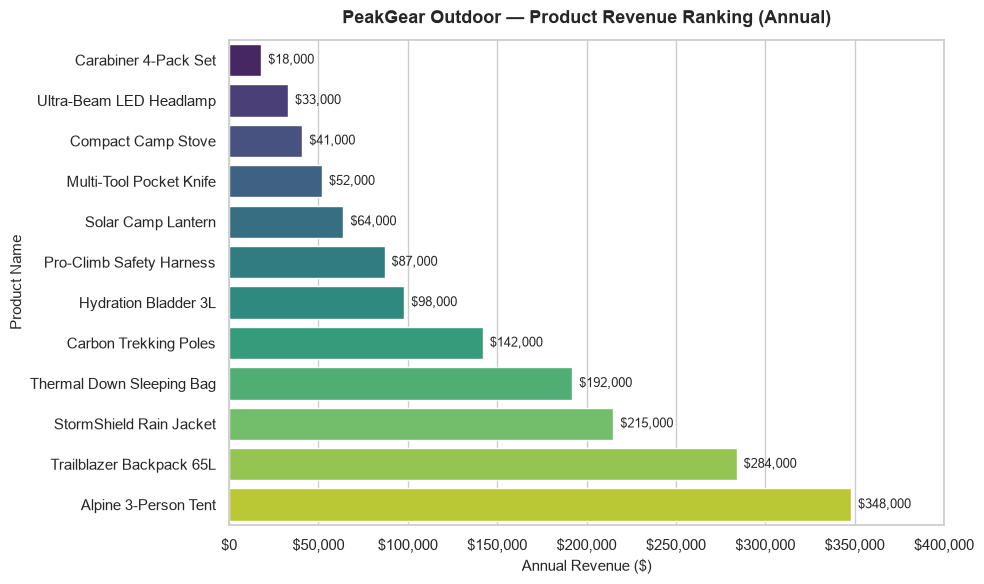

In [16]:
# Step 1: ALWAYS sort the DataFrame before creating a ranking chart
# Sorting ascending=True ensures the highest-revenue item is displayed at the top in horizontal barplots
df_sorted = df.sort_values(by="revenue", ascending=True).reset_index(drop=True)

# Step 2: Create horizontal bar chart
plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=df_sorted,
    x="revenue",
    y="product",
    hue="product",
    palette="viridis",
    legend=False
)

# Customize title and labels
plt.title("PeakGear Outdoor — Product Revenue Ranking (Annual)", fontsize=13, fontweight="bold", pad=12)
plt.xlabel("Annual Revenue ($)", fontsize=11)
plt.ylabel("Product Name", fontsize=11)
plt.gca().xaxis.set_major_formatter('${x:,.0f}')
plt.xlim(0, df_sorted["revenue"].max() * 1.15)

# Add exact value annotations at the tip of each bar
for p in ax.patches:
    width = p.get_width()
    ax.annotate(f"${width:,.0f}",
                (width, p.get_y() + p.get_height() / 2.),
                va='center', ha='left', fontsize=9, xytext=(5, 0),
                textcoords='offset points')

plt.tight_layout()
plt.show()


## 7. Plotly Express Visualization (Interactive Web Chart)

Plotly Express makes it seamless to build interactive ranking charts with continuous color scales that reinforce rank visually.
- **Hover** over any bar to view the exact revenue.
- The darker gradient immediately draws visual attention to top performers.


In [17]:
# For Plotly horizontal bars, sort ascending so the largest bar appears at the top
df_px_sorted = df.sort_values(by="revenue", ascending=True)

fig = px.bar(
    df_px_sorted,
    x="revenue",
    y="product",
    orientation="h",
    color="revenue",
    color_continuous_scale="Blues",
    title="<b>Interactive Product Revenue Ranking (Sorted)</b>",
    labels={"revenue": "Annual Revenue ($)", "product": "Product Name"},
    text_auto="$,.0f"
)

# Clean up layout
fig.update_layout(
    xaxis_title="Annual Revenue ($)",
    yaxis_title="",
    template="plotly_white",
    coloraxis_showscale=False # Clean look
)

fig.show()


## 8. Interpretation

By studying the sorted horizontal chart, several clear conclusions emerge:

1. **Clear Top Tier (The Superstar Items):**
   - The **Alpine 3-Person Tent** ranks #1 with **$348,000** in revenue.
   - The **Trailblazer Backpack 65L** is a strong #2 at **$284,000**, followed by the **StormShield Rain Jacket** at **$215,000**.
   - These top 3 products clearly form the primary financial engine of the business.

2. **The Middle Tier (Steady Contributors):**
   - The *Thermal Sleeping Bag* ($192k), *Trekking Poles* ($142k), *Hydration Bladder* ($98k), and *Safety Harness* ($87k) provide dependable baseline sales.

3. **The Long Tail (Bottom Laggards):**
   - The lowest-ranked product is the **Carabiner 4-Pack Set** at **$18,000**, followed by the **Ultra-Beam LED Headlamp** ($33,000) and **Compact Camp Stove** ($41,000).
   - The #1 product generates nearly **20 times more revenue** than the #12 product.


## 9. Key Insights & Recommended Business Actions

### What Happened?
- The catalog exhibits classic **Pareto distribution (80/20 rule)** behavior. A small handful of high-ticket items generate the vast majority of company cash flow.

### Actionable Business Recommendations:
1. **Safeguard Supply Chains for Top 3 Items:**
   - A stockout in tents, backpacks, or rain jackets would immediately damage quarterly company earnings. Establish safety buffer stock and multi-vendor sourcing for these three items.
2. **Product Bundling for Long-Tail Accessories:**
   - Items like the *Carabiner Set* ($18k) and *Headlamp* ($33k) have low standalone revenue. Bundle them as discounted add-ons during tent and backpack checkout to lift attachment rates.
3. **Evaluate Rationalization:**
   - Review whether maintaining inventory and warehouse shelf space for the *Carabiner Set* justifies its low annual return, or if it should be transitioned to a direct-ship vendor model.

---

### Common Analytical Mistake to Avoid:
> **Mistake: Leaving Ranking Visualizations Unsorted or Alphabetical**  
> Never present a ranking chart sorted alphabetically by product name! Alphabetical sorting turns a decision-making visual into a phone book, forcing executives to scan all 12 bars repeatedly to answer basic questions like *"What is our third-best product?"*. Always sort by the quantitative metric of interest.


## 10. Practice Exercises

### Exercise 1: Chart Interpretation
Based on the ranking chart:
1. What is the revenue difference in dollars between the #1 product (*Alpine Tent*) and the #2 product (*Trailblazer Backpack*)?
2. How many total products generated over $100,000 in annual revenue?
3. Why is a horizontal bar chart preferable to a vertical bar chart when presenting this product list?


### Exercise 2: Modify Chart Settings (Top-5 Filter)
In business presentations, executives often request a focused **Top-5** view.
In the code cell below:
- Filter `df` to retain only the **Top 5** products by revenue.
- Create a Seaborn horizontal bar chart using the `'crest'` color palette.
- Set an appropriate title: *"Top 5 Revenue Generating Products"*.


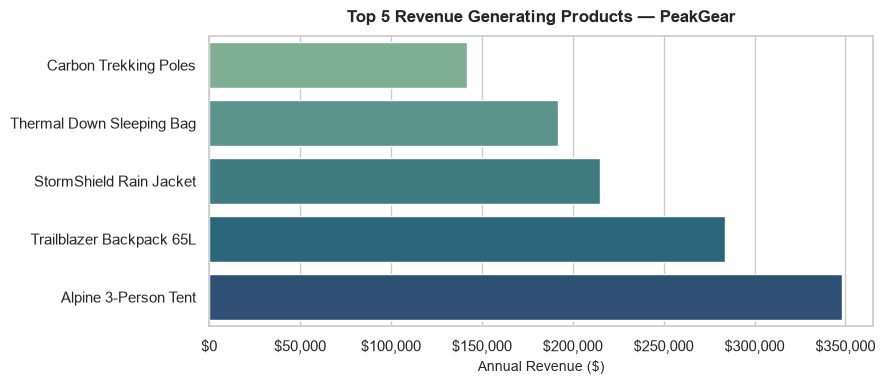

In [18]:
# Exercise 2: Student Code
# 1. Filter the top 5 products and sort ascending for display
top5_df = df.sort_values(by="revenue", ascending=False).head(5)
top5_df = top5_df.sort_values(by="revenue", ascending=True)

# 2. Create Seaborn horizontal barplot
plt.figure(figsize=(9, 4))
sns.barplot(
    data=top5_df,
    x="revenue",
    y="product",
    hue="product",
    palette="crest",
    legend=False
)

plt.title("Top 5 Revenue Generating Products — PeakGear", fontsize=12, fontweight="bold", pad=10)
plt.xlabel("Annual Revenue ($)", fontsize=10)
plt.ylabel("")
plt.gca().xaxis.set_major_formatter('${x:,.0f}')
plt.tight_layout()
plt.show()


### Exercise 3: Answer a Business Question (Concentration Ratio)
Calculate the **Revenue Share (%)** of the **Top 3 products** combined relative to total company revenue:
$$\text{Top-3 Share} = \left( \frac{\sum \text{Top 3 Revenue}}{\sum \text{Total Catalog Revenue}} \right) \times 100$$


In [19]:
# Exercise 3: Student Code
total_revenue = df["revenue"].sum()
top3_revenue = df.sort_values(by="revenue", ascending=False).head(3)["revenue"].sum()
top3_share_pct = (top3_revenue / total_revenue) * 100

print(f"Total Catalog Revenue: ${total_revenue:,.2f}")
print(f"Top 3 Products Combined Revenue: ${top3_revenue:,.2f}")
print(f"Top 3 Revenue Concentration: {top3_share_pct:.1f}% of total revenue")


Total Catalog Revenue: $1,574,000.00
Top 3 Products Combined Revenue: $847,000.00
Top 3 Revenue Concentration: 53.8% of total revenue


## 11. Challenge Activity

**Bottom-N Analysis for Inventory Rationalization:**  
Companies often leak margin by holding slow-moving inventory.

1. Filter the dataset for the **Bottom 4** products.
2. Build an interactive horizontal bar chart using Plotly Express with a warning color palette (`color_continuous_scale="Reds"`).
3. Formulate two specific recommendations for the merchandising team regarding how to handle these 4 items (e.g., discontinuation, discounting, or bundling).


In [20]:
# Challenge Activity: Bottom-4 Analysis
bottom4_df = df.sort_values(by="revenue", ascending=True).head(4)

fig_bottom = px.bar(
    bottom4_df,
    x="revenue",
    y="product",
    orientation="h",
    color="revenue",
    color_continuous_scale="Reds",
    title="<b>Bottom 4 Low-Revenue Products (Rationalization Candidates)</b>",
    labels={"revenue": "Annual Revenue ($)", "product": "Product"},
    text_auto="$,.0f"
)
fig_bottom.update_layout(template="plotly_white", coloraxis_showscale=False)
fig_bottom.show()


## 12. Key Takeaways

- **Always Sort Rankings:** An unsorted ranking chart fails its primary analytical purpose. Always sort descending or ascending based on your layout.
- **Horizontal Orientation for Text:** When category names exceed 6–8 characters, horizontal bar charts prevent unsightly rotated labels and improve reading speed.
- **Identify Revenue Skew:** Most retail catalogs follow power-law or Pareto distributions. Identify your top revenue drivers early to protect core cash flow.
- **Complement with Direct Value Labels:** Placing formatted dollar labels at the end of each bar eliminates the need for viewers to visually trace grid lines back to the axis.
